# K-Means Clustering

## Importing the libraries

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import pandas_gbq
import pandas as pd
import sklearn
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [27]:
#Base Stats

## Importing the dataset

In [28]:
#Change the date to the previous day
query = """
SELECT 
*
FROM `perceptive-ivy-290216.ncaab.player_stats_freshman`
# WHERE SEASON='2022-23'
"""
project_id = "perceptive-ivy-290216"
player_stats = pandas_gbq.read_gbq(query, project_id=project_id, dialect='standard')
player_stats=player_stats.fillna(0)

Downloading: 100%|██████████|


In [29]:
# dataset=player_stats[(player_stats['W']>10)&(player_stats['MIN']>0)]
dataset=player_stats
dataset=dataset[['Player','Season','MPG', 'PPG', 'FGM', 'FGA', 'FGPercent',
       '3PM', '3PA', '3PPercent', 'FTM', 'FTA', 'FTPercent', 'ORB', 'DRB',
       'RPG', 'APG', 'SPG', 'BPG', 'TOV']]
dataset.head()

,Player,Season,MPG,PPG,FGM,FGA,FGPercent,3PM,3PA,3PPercent,FTM,FTA,FTPercent,ORB,DRB,RPG,APG,SPG,BPG,TOV
0,M.J. Thomas,2025,28.6,11.2,3.9,8.1,.482,0.0,0.1,.000,3.4,4.8,.700,3.1,4.8,7.8,1.2,0.9,0.8,1.6
1,Samet Yigitoglu,2025,24.3,10.4,4.0,7.1,.558,0.0,0.1,.250,2.4,4.1,.583,2.4,3.9,6.3,1.1,0.6,0.9,1.4
2,Lathan Sommerville,2025,20.8,7.9,2.7,5.4,.503,0.0,0.3,.125,2.5,2.9,.860,1.2,2.8,4.1,0.6,0.4,0.6,1.1
3,"Morez Johnson, Jr.",2025,17.8,7.2,2.6,3.9,.667,0.0,0.0,.000,2.0,3.2,.619,2.7,3.9,6.6,0.2,0.4,1.1,0.8
4,Hank Alvey,2025,25.1,7.1,2.7,5.8,.470,0.0,0.2,.143,1.6,2.2,.746,1.6,3.3,4.9,0.9,0.6,0.6,0.8


In [30]:
# X = dataset.iloc[:,3:].values
X = dataset.loc[:,['MPG', 'PPG', 'FGM', 'FGA', 'FGPercent',
       '3PM', '3PA', '3PPercent', 'FTM', 'FTA', 'FTPercent', 'ORB', 'DRB',
       'RPG', 'APG', 'SPG', 'BPG', 'TOV']].values
X

array([['28.6', '11.2', '3.9', ..., '0.9', '0.8', '1.6'],
       ['24.3', '10.4', '4.0', ..., '0.6', '0.9', '1.4'],
       ['20.8', '7.9', '2.7', ..., '0.4', '0.6', '1.1'],
       ...,
       ['28.1', '10.9', '4.0', ..., '0.7', '1.5', '1.0'],
       ['32.0', '16.9', '6.3', ..., '0.7', '1.5', '2.4'],
       ['27.8', '9.8', '3.3', ..., '0.4', '1.5', '1.9']], dtype=object)

In [31]:
dataset_2=dataset.iloc[:,2:]
scaler=StandardScaler()
segmentation_std=scaler.fit_transform(dataset_2)
dataset_2

,MPG,PPG,FGM,FGA,FGPercent,3PM,3PA,3PPercent,FTM,FTA,FTPercent,ORB,DRB,RPG,APG,SPG,BPG,TOV
0,28.6,11.2,3.9,8.1,.482,0.0,0.1,.000,3.4,4.8,.700,3.1,4.8,7.8,1.2,0.9,0.8,1.6
1,24.3,10.4,4.0,7.1,.558,0.0,0.1,.250,2.4,4.1,.583,2.4,3.9,6.3,1.1,0.6,0.9,1.4
2,20.8,7.9,2.7,5.4,.503,0.0,0.3,.125,2.5,2.9,.860,1.2,2.8,4.1,0.6,0.4,0.6,1.1
3,17.8,7.2,2.6,3.9,.667,0.0,0.0,.000,2.0,3.2,.619,2.7,3.9,6.6,0.2,0.4,1.1,0.8
4,25.1,7.1,2.7,5.8,.470,0.0,0.2,.143,1.6,2.2,.746,1.6,3.3,4.9,0.9,0.6,0.6,0.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8687,26.2,12.0,4.1,8.0,.508,1.0,2.8,.348,2.9,3.7,.780,1.8,6.1,7.8,1.2,1.2,1.5,1.5
8688,25.3,9.8,3.4,7.9,.429,1.6,4.3,.362,1.4,2.2,.642,1.4,3.4,4.8,1.1,0.8,1.5,1.3
8689,28.1,10.9,4.0,8.4,.476,1.6,3.8,.433,1.2,1.8,.700,2.3,5.8,8.0,0.8,0.7,1.5,1.0
8690,32.0,16.9,6.3,13.0,.486,2.0,5.1,.389,2.3,3.3,.685,1.5,6.8,8.3,2.1,0.7,1.5,2.4


In [32]:
pca=PCA()
pca.fit(segmentation_std)

PCA()

In [33]:
pd.set_option('display.float_format', '{:.2f}'.format)
pd.DataFrame(pca.explained_variance_ratio_)

,0
0,0.39
1,0.26
2,0.09
3,0.05
4,0.04
5,0.04
6,0.03
7,0.03
8,0.02
9,0.02


## Using the elbow method to find the optimal number of clusters

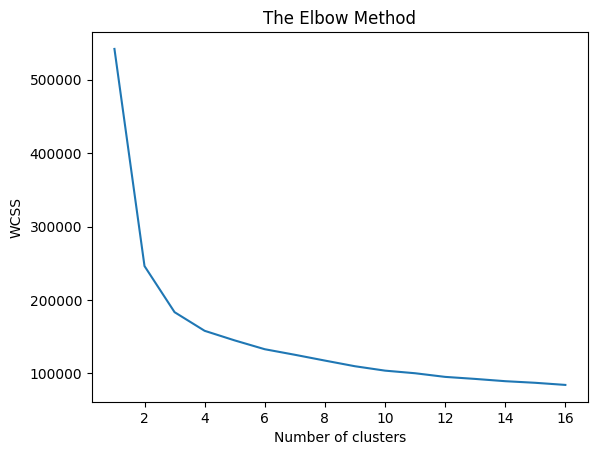

In [34]:
from sklearn.cluster import KMeans
wcss = []
for i in range(1, 17):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
plt.plot(range(1, 17), wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

## Training the K-Means model on the dataset

In [35]:
kmeans = KMeans(n_clusters = 12, init = 'k-means++', random_state = 42)
y_kmeans = kmeans.fit_predict(X)
y_kmeans

array([ 3, 11,  9, ...,  3, 10,  1], dtype=int32)

In [36]:
cluster_0=dataset[y_kmeans==0].copy()
cluster_0["cluster"]="cluster_0"
cluster_1=dataset[y_kmeans==1].copy()
cluster_1["cluster"]="cluster_1"
cluster_2=dataset[y_kmeans==2].copy()
cluster_2["cluster"]="cluster_2"
cluster_3=dataset[y_kmeans==3].copy()
cluster_3["cluster"]="cluster_3"
cluster_4=dataset[y_kmeans==4].copy()
cluster_4["cluster"]="cluster_4"
cluster_5=dataset[y_kmeans==5].copy()
cluster_5["cluster"]="cluster_5"
cluster_6=dataset[y_kmeans==6].copy()
cluster_6["cluster"]="cluster_6"
cluster_7=dataset[y_kmeans==7].copy()
cluster_7["cluster"]="cluster_7"
cluster_8=dataset[y_kmeans==8].copy()
cluster_8["cluster"]="cluster_8"
cluster_9=dataset[y_kmeans==9].copy()
cluster_9["cluster"]="cluster_9"
cluster_10=dataset[y_kmeans==10].copy()
cluster_10["cluster"]="cluster_10"
cluster_11=dataset[y_kmeans==11].copy()
cluster_11["cluster"]="cluster_11"
cluster_12=dataset[y_kmeans==12].copy()
cluster_12["cluster"]="cluster_12"
cluster_final=pd.concat([cluster_0, cluster_1, cluster_2, cluster_3, cluster_4, cluster_5, cluster_6, cluster_7, cluster_8, cluster_9,
                         cluster_10, cluster_11, cluster_12], ignore_index=True)
cluster_final.tail()

,Player,Season,MPG,PPG,FGM,FGA,FGPercent,3PM,3PA,3PPercent,...,FTA,FTPercent,ORB,DRB,RPG,APG,SPG,BPG,TOV,cluster
8687,Nick Ward,2017,19.8,13.9,5.2,8.7,.592,0.0,0.0,.000,...,5.7,.615,2.8,3.7,6.5,0.4,0.3,1.5,1.7,cluster_11
8688,Nathan Boothe,2013,24.6,8.3,3.5,7.7,.456,0.1,0.3,.286,...,1.7,.723,1.6,3.6,5.2,0.7,0.6,1.5,1.1,cluster_11
8689,Xavier Cooks,2015,25.8,7.8,3.0,5.7,.536,0.1,0.5,.188,...,2.6,.614,1.8,4.2,6.1,1.5,0.8,1.5,1.8,cluster_11
8690,William Lee,2015,23.7,8.0,2.9,6.1,.485,0.6,1.4,.457,...,1.9,.794,1.7,4.3,6.0,1.1,0.5,1.5,1.4,cluster_11
8691,Stan Okoye,2010,21.9,14.2,5.5,10.6,.520,0.7,2.3,.288,...,4.3,.587,2.5,4.1,6.6,0.5,0.8,1.5,1.7,cluster_11


In [37]:
cluster_final

,Player,Season,MPG,PPG,FGM,FGA,FGPercent,3PM,3PA,3PPercent,...,FTA,FTPercent,ORB,DRB,RPG,APG,SPG,BPG,TOV,cluster
0,Bryson Tucker,2025,16.8,5.4,2.1,5.5,.378,0.1,0.9,.150,...,1.6,.722,0.7,2.2,2.9,0.6,0.3,0.0,0.6,cluster_0
1,Jaquan Johnson,2025,17.5,6.6,2.0,4.3,.472,0.4,1.1,.389,...,3.1,.696,0.5,1.8,2.4,2.4,1.5,0.0,1.2,cluster_0
2,Kohen Rowbatham,2025,19.4,7.3,2.6,6.6,.385,0.5,1.9,.275,...,2.2,.767,0.1,1.1,1.3,1.4,0.4,0.0,1.9,cluster_0
3,Derrion Reid,2025,16.3,7.1,2.4,5.6,.436,0.5,1.9,.257,...,2.9,.566,1.1,2.1,3.2,0.8,0.3,0.3,0.9,cluster_0
4,Sebastian Rancik,2025,18.4,6.3,2.1,4.9,.422,0.5,2.0,.262,...,2.3,.696,0.7,2.3,2.9,0.7,0.4,0.2,0.9,cluster_0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8687,Nick Ward,2017,19.8,13.9,5.2,8.7,.592,0.0,0.0,.000,...,5.7,.615,2.8,3.7,6.5,0.4,0.3,1.5,1.7,cluster_11
8688,Nathan Boothe,2013,24.6,8.3,3.5,7.7,.456,0.1,0.3,.286,...,1.7,.723,1.6,3.6,5.2,0.7,0.6,1.5,1.1,cluster_11
8689,Xavier Cooks,2015,25.8,7.8,3.0,5.7,.536,0.1,0.5,.188,...,2.6,.614,1.8,4.2,6.1,1.5,0.8,1.5,1.8,cluster_11
8690,William Lee,2015,23.7,8.0,2.9,6.1,.485,0.6,1.4,.457,...,1.9,.794,1.7,4.3,6.0,1.1,0.5,1.5,1.4,cluster_11


In [50]:
cluster_final[cluster_final["Player"]=='Cam Reddish']

,Player,Season,MPG,PPG,FGM,FGA,FGPercent,3PM,3PA,3PPercent,...,FTA,FTPercent,ORB,DRB,RPG,APG,SPG,BPG,TOV,cluster
7001,Cam Reddish,2019,29.70,13.50,4.3,12.0,.356,2.5,7.4,.333,...,3.2,.772,0.6,3.1,3.7,1.9,1.6,0.6,2.7,cluster_8


In [43]:
cluster_final["MPG"]=cluster_final["MPG"].astype(float)
cluster_final["PPG"]=cluster_final["PPG"].astype(float)

## Visualising the clusters

In [44]:
fig=px.scatter(cluster_final, 
               x="MPG",
               y="PPG", 
               color='cluster',
               hover_data=['Player','MPG', 'PPG', 'FGM', 'FGA', 'FGPercent',
       '3PM', '3PA', '3PPercent', 'FTM', 'FTA', 'FTPercent', 'ORB', 'DRB',
       'RPG', 'APG', 'SPG', 'BPG', 'TOV','Season'],
               height=700, 
               width=900,
        )

# fig2=px.scatter(Final[Final['value']==1], x="POINTS_PER_MIN_", y="CATCH_SHOOT_FGM_", color_discrete_sequence=['blue'],
#         hover_data=["PLAYER_NAME","Salary"],
#         height=700, width=900,
#         )

# fig3=px.scatter(Final[Final['value']==2], x="POINTS_PER_MIN_", y="CATCH_SHOOT_FGM_", color_discrete_sequence=['orange'],
#         hover_data=["PLAYER_NAME","Salary"],
#         height=700, width=900,
#         )
# fig4=px.scatter(kmeans.cluster_centers_, kmeans.cluster_centers_[:, 1], kmeans.cluster_centers_[:, 0], color_discrete_sequence=['yellow'],
#         height=1000, width=1000,
#         )
# fig4.update_traces(marker=dict(size=20))

# fig.add_traces(
#     list(fig2.select_traces())
# )

# fig.add_traces(
#     list(fig3.select_traces())
# )

# fig.add_traces(
#     list(fig4.select_traces())
# )

# fig.update_layout(
#     xaxis_title="MIN",
#     yaxis_title="FGA",
#     # xaxis_range=[0,1]
# )

fig.show()

In [47]:
cluster_final[cluster_final["cluster"]=='cluster_8'].to_csv("base_cluster.csv")